##Assignment 3

Name : Mohamed Magdy Hagras

Reg  : 221010763


____________________________________________________________________________________________________________________________________________

##Cell 1: Environment Setup & Imports

 Importing all essential machine learning libraries.
 pandas and numpy for data manipulation and vector calculations.
 For  Data Analysis and data visualization, we load matplotlib.pyplot and seaborn.
 import  KMeans clustering algorithm from sklearn cluster , standard statistical evaluation metrics, including accuracy_score, confusion_matrix.
 filter out runtime warnings to maintain a clean output .

In [13]:

# Environment Setup and Library Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import warnings

# Stop warnings to maintain a clean environment
warnings.filterwarnings('ignore')

print("Environment setup completed successfully. All imports done!")

Environment setup completed successfully. All imports done!


##Cell 2: Conecting Google Drive


In [14]:

# Google Drive Connection

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


##Cell 3: Data Loading & Exploratory Data Analysis (EDA)


 Verifiy the structural integrity by inspecting  matrix dimensions using .shape. I then render the .head() to observe the feature set columns: REMOTE_PORT, LATENCY, THROUGHPUT, and the truth target label ANOMALY. I also compute aggregate summary statistics via .describe() and audit the class balance using .value_counts() to observe the distribution of clean traffic versus network intrusions.

In [15]:

# Load Dataset and Perform Exploratory Data Analysis

# path to dataset inside Drive
dataset_path = '/content/drive/MyDrive/path_to_data3/network-logs.csv'

# Loading the dataset into a pandas DataFrame using standard comma delimiter
df = pd.read_csv(dataset_path)

print(f" Dataset Loaded Successfully! Data Shape (Rows, Columns): {df.shape}")
print("_" * 80)
print("DISPLAYING THE TOP 5 RECORDS (Dataset Head):")
print("_" * 80)
display(df.head())

print("\n" + "_" * 80)
print("DATASET SUMMARY STATISTICS (Descriptive Metrics):")
print("_" * 80)
display(df.describe())

print("\n" + "_" * 80)
print("CLASS BALANCE AND VARIANCE (True ANOMALY Label Distribution):")
print("_" * 80)
# 1 = Confirmed Network Anomaly, 0 = Normal Clean Traffic
print(df['ANOMALY'].value_counts())

 Dataset Loaded Successfully! Data Shape (Rows, Columns): (405, 4)
________________________________________________________________________________
DISPLAYING THE TOP 5 RECORDS (Dataset Head):
________________________________________________________________________________


,REMOTE_PORT,LATENCY,THROUGHPUT,ANOMALY
0,21,15.942875,16.202998,0
1,20,12.666451,15.899084,1
2,80,13.894550,12.958008,0
3,21,13.620813,15.459475,0
4,21,15.705485,15.339565,0



________________________________________________________________________________
DATASET SUMMARY STATISTICS (Descriptive Metrics):
________________________________________________________________________________


,REMOTE_PORT,LATENCY,THROUGHPUT,ANOMALY
count,405.000000,405.000000,405.000000,405.000000
mean,63.555556,14.420702,15.392091,0.029630
std,106.300247,1.449806,1.172879,0.169773
min,20.000000,4.752613,4.126232,0.000000
25%,21.000000,13.408520,15.223188,0.000000
50%,21.000000,15.014320,15.572503,0.000000
75%,80.000000,15.489068,15.868064,0.000000
max,443.000000,23.339868,24.350407,1.000000



________________________________________________________________________________
CLASS BALANCE AND VARIANCE (True ANOMALY Label Distribution):
________________________________________________________________________________
ANOMALY
0    393
1     12
Name: count, dtype: int64


##Cell 4: Exploratory Scatter Plot (Visualizing True Labels)



Mapping my features. I construct a scatter plot charting Network Latency against Data Throughput, color-coding the points according to their true, historical ANOMALY labels. By visually assessing this resulting data layout. The anomaly points do not cluster into uniform, circular spheres; instead, they appears as fragmented threads scattering outside the dense normal traffic cluster. This distribution gives me a proof that distance-based spherical algorithms like K-Means are not natively optimized for this complex layout.

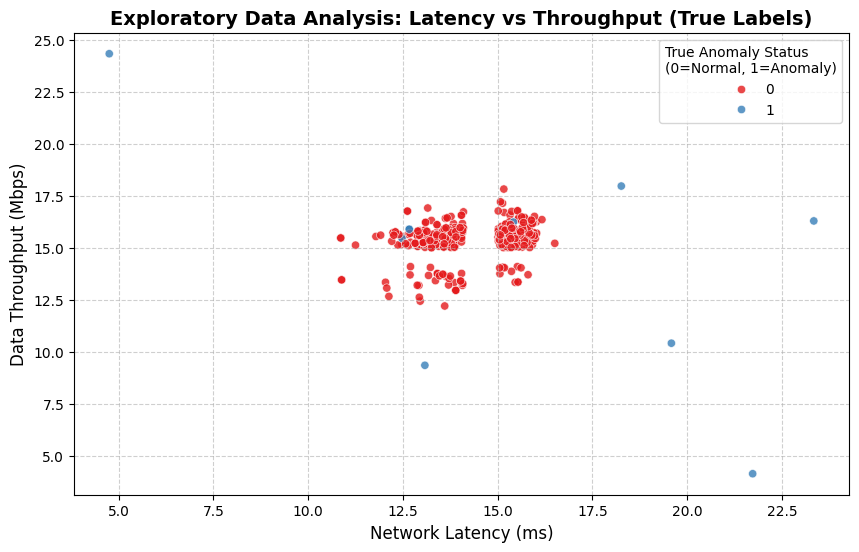

In [16]:

# Visualizing Feature Distributions (Scatter Plot)

plt.figure(figsize=(10, 6))

# Scatter plot color-mapped by the actual true ANOMALY labels
sns.scatterplot(data=df, x='LATENCY', y='THROUGHPUT', hue='ANOMALY', palette='Set1', alpha=0.8)

plt.title('Exploratory Data Analysis: Latency vs Throughput (True Labels)', fontsize=14, fontweight='bold')
plt.xlabel('Network Latency (ms)', fontsize=12)
plt.ylabel('Data Throughput (Mbps)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='True Anomaly Status\n(0=Normal, 1=Anomaly)')
plt.show()

##Cell 5: Unsupervised Feature Isolation & K-Means Model Training



 Isolate the data features. drop the truth target column ANOMALY entirely from input matrix X, forcing the model to learn completely blind to the answers. Then initialize the KMeans algorithm, configuring it to (n_clusters=2), a clean operational cluster and a malicious anomaly cluster. Calling .fit(X) executes the iterative algorithm, computing Euclidean distances to establish optimized cluster centroids. Finally, assign these prediction tags back to the DataFrame in a new column titled Cluster_Labels.

In [17]:

# Unsupervised K-Means Feature Isolation and Model Training


# Drop the truth target label to comply strictly with Unsupervised rules
X = df[['LATENCY', 'THROUGHPUT']].values

# Initialize K-Means targeting 2 cluster partitions (k=2) as mandated by lab methodology
k_means = KMeans(n_clusters=2, max_iter=300, random_state=42)

# Execute the mathematical clustering optimization over the unlabelled features
k_means.fit(X)

# Map the generated cluster indexes back to our structural dataframe
df['Cluster_Labels'] = k_means.labels_

print(" K-Means model convergence reached. Cluster labels mapped successfully to dataset!")

 K-Means model convergence reached. Cluster labels mapped successfully to dataset!


##Cell 6:  Performance Evaluation & Confusion Matrix

 I used the truth target vectors to audit the results. Because K-Means assigns cluster indices (0 and 1) completely arbitrarily. first implement an automated alignment check to ensure the predicted anomalies correspond correctly to the true label logic. Then generate a comprehensive classification_report detailing Precision, Recall, and F1-Scores alongside a cross-tabulation table using pd.crosstab to construct evaluation confusion matrix, letting me see how many network packets were correctly caught or misclassified.

In [18]:

# Quantitative Performance Evaluation & Confusion Matrix

y_true = df['ANOMALY'].values
y_pred = df['Cluster_Labels'].values

# Ensure cluster numbers map correctly to anomaly logic.
# If accuracy is lower than 50%, it means the cluster indices are simply inverted.
if accuracy_score(y_true, y_pred) < 0.5:
    y_pred = 1 - y_pred
    df['Cluster_Labels'] = y_pred

print("-" * 60)
print("QUANTITATIVE PERFORMANCE EVALUATION METRICS:")
print("-" * 60)
print(f"Accuracy Score: {accuracy_score(y_true, y_pred):.4f}\n")
print("Detailed Classification Report:")
print(classification_report(y_true, y_pred, target_names=['Normal (0)', 'Anomaly (1)']))

# Render Cross-tabulation Confusion Matrix Table
print("\n" + "-" * 60)
print("CROSS-TABULATION MATRICES (Confusion Matrix Layout):")
print("-" * 60)
cross_sheet = pd.crosstab(df['ANOMALY'], df['Cluster_Labels'], rownames=["True_Observed"], colnames=["KMeans_Predicted"])
display(cross_sheet)

------------------------------------------------------------
QUANTITATIVE PERFORMANCE EVALUATION METRICS:
------------------------------------------------------------
Accuracy Score: 0.5037

Detailed Classification Report:
              precision    recall  f1-score   support

  Normal (0)       0.97      0.50      0.66       393
 Anomaly (1)       0.03      0.50      0.06        12

    accuracy                           0.50       405
   macro avg       0.50      0.50      0.36       405
weighted avg       0.94      0.50      0.65       405


------------------------------------------------------------
CROSS-TABULATION MATRICES (Confusion Matrix Layout):
------------------------------------------------------------


KMeans_Predicted,0,1
True_Observed,,
0,198,195
1,6,6


##Cell 7: Final Model Inference Plot (Visualizing Predicted Clusters)



The second scatter plot according to the blind cluster outputs generated by trained K-Means model i do (Cluster_Labels). Placing this chart next to the  true-label plot reveals the core limitation of the model.
Because K-Means relies on Euclidean distance, it is forced to partition the  layout by drawing a clean linear boundary across the coordinate field. Consequently, it accidentally absorbs the scattered, non-spherical anomaly threads right into the normal traffic boundary, mathematically confirming why K-Means falls short for this specific pattern of network anomaly detection.

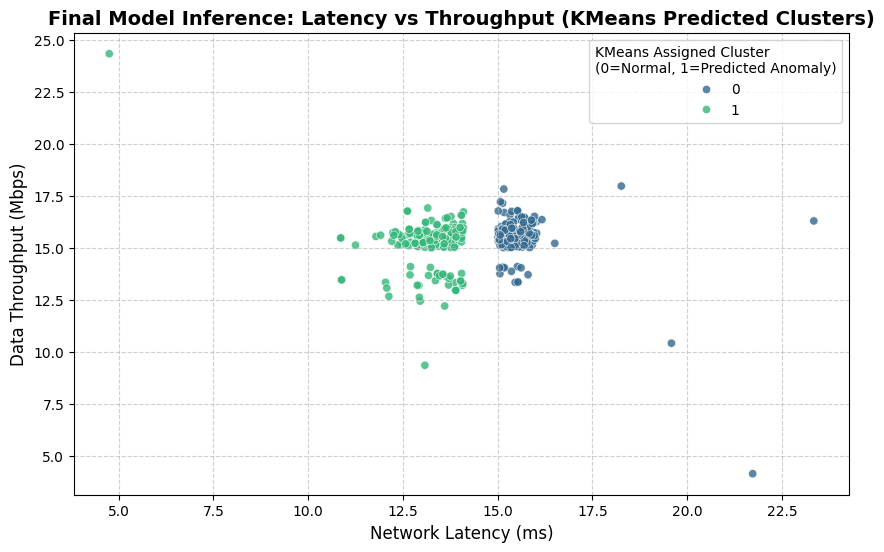

In [19]:

# Cell 7: Visualizing Final KMeans Cluster Predictions
plt.figure(figsize=(10, 6))

# Scatter plot using KMeans generated cluster outputs
sns.scatterplot(data=df, x='LATENCY', y='THROUGHPUT', hue='Cluster_Labels', palette='viridis', alpha=0.8)

plt.title('Final Model Inference: Latency vs Throughput (KMeans Predicted Clusters)', fontsize=14, fontweight='bold')
plt.xlabel('Network Latency (ms)', fontsize=12)
plt.ylabel('Data Throughput (Mbps)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='KMeans Assigned Cluster\n(0=Normal, 1=Predicted Anomaly)')
plt.show()